In [75]:
!pip install understatapi pandas --quiet

In [76]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2025')

df = pd.DataFrame(matches)

In [77]:
match_ids = ['28786', '28793', '28806', '28808',
             '28827', '28836', '28839', '28851',
             '28859', '28869']

In [78]:
for match_id in match_ids:
    print("Processing match:", match_id)

Processing match: 28786
Processing match: 28793
Processing match: 28806
Processing match: 28808
Processing match: 28827
Processing match: 28836
Processing match: 28839
Processing match: 28851
Processing match: 28859
Processing match: 28869


In [79]:
import pandas as pd

all_shots = []

for match_id in match_ids:
    try:
        shot_data = client.match(match=match_id).get_shot_data()

        shots = shot_data['h'] + shot_data['a']

        if len(shots) > 0:
            df_temp = pd.DataFrame(shots)
            df_temp['match_id'] = match_id
            all_shots.append(df_temp)

    except Exception as e:
        print(f"Error with {match_id}: {e}")

# Combine
shots_df = pd.concat(all_shots, ignore_index=True)

print("Total shots:", len(shots_df))

Total shots: 220


In [80]:
all_shots = []

for match_id in match_ids:

    match_id = str(match_id)  # IMPORTANT FIX

    print("Processing:", match_id)

    try:
        shot_data = client.match(match=match_id).get_shot_data()

        shots = shot_data['h'] + shot_data['a']

        df_temp = pd.DataFrame(shots)
        df_temp['match_id'] = match_id

        all_shots.append(df_temp)

    except Exception as e:
        print(f"Error with {match_id}: {e}")

shots_df = pd.concat(all_shots, ignore_index=True)

print("Total shots:", len(shots_df))

Processing: 28786
Processing: 28793
Processing: 28806
Processing: 28808
Processing: 28827
Processing: 28836
Processing: 28839
Processing: 28851
Processing: 28859
Processing: 28869
Total shots: 220


In [81]:
print(shots_df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [82]:
shots_df['team'] = shots_df['h_team']  # default = home

shots_df.loc[shots_df['h_a'] == 'a', 'team'] = shots_df['a_team']

In [83]:
print(shots_df['match_id'].value_counts())

match_id
28786    31
28836    28
28851    25
28839    25
28793    21
28808    21
28806    20
28827    17
28859    17
28869    15
Name: count, dtype: int64


In [84]:
shots_df[['match_id', 'h_team', 'a_team']].drop_duplicates().head(20)

,match_id,h_team,a_team
0,28786,Manchester United,Arsenal
31,28793,Arsenal,Leeds
52,28806,Liverpool,Arsenal
72,28808,Arsenal,Nottingham Forest
93,28827,Arsenal,Manchester City
110,28836,Newcastle United,Arsenal
138,28839,Arsenal,West Ham
163,28851,Fulham,Arsenal
188,28859,Arsenal,Crystal Palace
205,28869,Burnley,Arsenal


In [85]:
shots_df['match_id'].nunique()

10

In [86]:
shots_df['team'].value_counts()

,count
team,
Arsenal,145
Manchester United,22
Liverpool,9
Fulham,9
Newcastle United,8
Crystal Palace,7
Manchester City,5
Nottingham Forest,5
West Ham,4


In [87]:
arsenal_df = shots_df[shots_df['team'] == 'Arsenal']

In [88]:
corners_df = arsenal_df[arsenal_df['situation'] == 'FromCorner']

print("Corner shots:", len(corners_df))

Corner shots: 33


In [89]:
print(corners_df[['player', 'X', 'Y', 'xG', 'situation']].head())

                player                   X                    Y  \
22  Riccardo Calafiori  0.9940000152587891                 0.49   
25     Martin Odegaard  0.8719999694824219   0.4209999847412109   
26           Ben White  0.7469999694824219  0.45799999237060546   
35      Jurriën Timber  0.9540000152587891   0.5020000076293946   
41      Jurriën Timber   0.950999984741211  0.49700000762939456   

                     xG   situation  
22   0.8442546129226685  FromCorner  
25  0.06685280054807663  FromCorner  
26   0.0184373389929533  FromCorner  
35  0.13262973725795746  FromCorner  
41  0.16368675231933594  FromCorner  


In [90]:
corners_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 22 to 209
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               33 non-null     object
 1   minute           33 non-null     object
 2   result           33 non-null     object
 3   X                33 non-null     object
 4   Y                33 non-null     object
 5   xG               33 non-null     object
 6   player           33 non-null     object
 7   h_a              33 non-null     object
 8   player_id        33 non-null     object
 9   situation        33 non-null     object
 10  season           33 non-null     object
 11  shotType         33 non-null     object
 12  match_id         33 non-null     object
 13  h_team           33 non-null     object
 14  a_team           33 non-null     object
 15  h_goals          33 non-null     object
 16  a_goals          33 non-null     object
 17  date             33 non-null     object


# Convert categorical columns to numeric

In [91]:
num_cols = ['X', 'Y', 'xG', 'minute', 'h_goals', 'a_goals']

for col in num_cols:
    corners_df[col] = pd.to_numeric(corners_df[col], errors='coerce')

/tmp/ipykernel_11542/2709366418.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corners_df[col] = pd.to_numeric(corners_df[col], errors='coerce')


In [92]:
corners_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, 22 to 209
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               33 non-null     object 
 1   minute           33 non-null     int64  
 2   result           33 non-null     object 
 3   X                33 non-null     float64
 4   Y                33 non-null     float64
 5   xG               33 non-null     float64
 6   player           33 non-null     object 
 7   h_a              33 non-null     object 
 8   player_id        33 non-null     object 
 9   situation        33 non-null     object 
 10  season           33 non-null     object 
 11  shotType         33 non-null     object 
 12  match_id         33 non-null     object 
 13  h_team           33 non-null     object 
 14  a_team           33 non-null     object 
 15  h_goals          33 non-null     int64  
 16  a_goals          33 non-null     int64  
 17  date             33 n

# True corner xG output

In [93]:
corners_df['xG'].sum()

np.float64(5.0497728139162055)

# Player dominance from corners

In [94]:
corners_df.groupby('player')['xG'].sum().sort_values(ascending=False)

,xG
player,
Gabriel,1.198562
Riccardo Calafiori,0.994387
Leandro Trossard,0.793195
Viktor Gyokeres,0.731960
Jurriën Timber,0.727531
Mikel Merino,0.142002
Noni Madueke,0.086600
Eberechi Eze,0.069643
William Saliba,0.067716


In [95]:
corners_df.groupby('player')['shotType'].sum().sort_values(ascending=False)

,shotType
player,
Eberechi Eze,RightFootRightFoot
Ben White,RightFoot
Martín Zubimendi,RightFoot
Leandro Trossard,LeftFootRightFootRightFootRightFoot
Ethan Nwaneri,LeftFootLeftFoot
Noni Madueke,LeftFootLeftFoot
Bukayo Saka,LeftFoot
Gabriel Martinelli,LeftFoot
Martin Odegaard,LeftFoot


# Shot location mapping

In [96]:
corners_df[['X', 'Y']]

,X,Y
22,0.994,0.490
25,0.872,0.421
26,0.747,0.458
35,0.954,0.502
41,0.951,0.497
42,0.958,0.517
43,0.969,0.508
61,0.861,0.562
66,0.910,0.532
69,0.871,0.634


# Share of total corner xG

In [97]:
corner_xg_by_player = corners_df.groupby('player')['xG'].sum()

share = corner_xg_by_player / corner_xg_by_player.sum()

print(share.sort_values(ascending=False))

player
Gabriel               0.237350
Riccardo Calafiori    0.196917
Leandro Trossard      0.157075
Viktor Gyokeres       0.144949
Jurriën Timber        0.144072
Mikel Merino          0.028121
Noni Madueke          0.017149
Eberechi Eze          0.013791
William Saliba        0.013410
Martin Odegaard       0.013239
Ethan Nwaneri         0.012746
Gabriel Martinelli    0.008378
Martín Zubimendi      0.006273
Ben White             0.003651
Bukayo Saka           0.002879
Name: xG, dtype: float64


# Combine both metrics

In [98]:
total_xg = corners_df.groupby('player')['xG'].sum()
avg_xg = corners_df.groupby('player')['xG'].mean()

player_profile = pd.concat([total_xg, avg_xg], axis=1)
player_profile.columns = ['total_xG', 'xG_per_shot']

In [99]:
print(total_xg)
print(avg_xg)
print(player_profile)
print(player_profile.columns)

player
Ben White             0.018437
Bukayo Saka           0.014539
Eberechi Eze          0.069643
Ethan Nwaneri         0.064366
Gabriel               1.198562
Gabriel Martinelli    0.042305
Jurriën Timber        0.727531
Leandro Trossard      0.793195
Martin Odegaard       0.066853
Martín Zubimendi      0.031676
Mikel Merino          0.142002
Noni Madueke          0.086600
Riccardo Calafiori    0.994387
Viktor Gyokeres       0.731960
William Saliba        0.067716
Name: xG, dtype: float64
player
Ben White             0.018437
Bukayo Saka           0.014539
Eberechi Eze          0.034822
Ethan Nwaneri         0.032183
Gabriel               0.299641
Gabriel Martinelli    0.042305
Jurriën Timber        0.121255
Leandro Trossard      0.198299
Martin Odegaard       0.066853
Martín Zubimendi      0.031676
Mikel Merino          0.071001
Noni Madueke          0.043300
Riccardo Calafiori    0.331462
Viktor Gyokeres       0.365980
William Saliba        0.067716
Name: xG, dtype: float64
      

In [100]:
num_cols = ['X', 'Y', 'xG', 'minute', 'h_goals', 'a_goals']

for col in num_cols:
    shots_df[col] = pd.to_numeric(shots_df[col], errors='coerce')

In [101]:
arsenal_df = shots_df[shots_df['team'] == 'Arsenal']

In [102]:
arsenal_df.info()
arsenal_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 22 to 219
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               145 non-null    object 
 1   minute           145 non-null    int64  
 2   result           145 non-null    object 
 3   X                145 non-null    float64
 4   Y                145 non-null    float64
 5   xG               145 non-null    float64
 6   player           145 non-null    object 
 7   h_a              145 non-null    object 
 8   player_id        145 non-null    object 
 9   situation        145 non-null    object 
 10  season           145 non-null    object 
 11  shotType         145 non-null    object 
 12  match_id         145 non-null    object 
 13  h_team           145 non-null    object 
 14  a_team           145 non-null    object 
 15  h_goals          145 non-null    int64  
 16  a_goals          145 non-null    int64  
 17  date             145

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,...,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction,team
22,638225,12,Goal,0.994,0.490,0.844255,Riccardo Calafiori,a,8129,FromCorner,...,Head,28786,Manchester United,Arsenal,0,1,2025-08-17 15:30:00,None,None,Arsenal
23,638228,25,SavedShot,0.870,0.693,0.058520,Gabriel Martinelli,a,7752,OpenPlay,...,RightFoot,28786,Manchester United,Arsenal,0,1,2025-08-17 15:30:00,Bukayo Saka,Pass,Arsenal
24,638232,34,SavedShot,0.777,0.422,0.060895,Martin Odegaard,a,2517,OpenPlay,...,LeftFoot,28786,Manchester United,Arsenal,0,1,2025-08-17 15:30:00,Ben White,TakeOn,Arsenal
25,638235,40,MissedShots,0.872,0.421,0.066853,Martin Odegaard,a,2517,FromCorner,...,LeftFoot,28786,Manchester United,Arsenal,0,1,2025-08-17 15:30:00,None,None,Arsenal
26,638236,40,MissedShots,0.747,0.458,0.018437,Ben White,a,7298,FromCorner,...,RightFoot,28786,Manchester United,Arsenal,0,1,2025-08-17 15:30:00,None,BallTouch,Arsenal


# Comparison to open play

In [103]:
arsenal_df = shots_df[shots_df['team'] == 'Arsenal']

open_play_xg = arsenal_df[arsenal_df['situation'] == 'OpenPlay']['xG'].mean()
corner_xg = corners_df['xG'].mean()

print("Open play xG/shot:", open_play_xg)
print("Corner xG/shot:", corner_xg)

Open play xG/shot: 0.11828125751091406
Corner xG/shot: 0.15302341860352137


# CREATE ZONES

In [104]:
def get_zone(x, y):
    x = float(x)
    y = float(y)

    # Close to goal area
    if x > 0.9:
        if y < 0.33:
            return "Near Post"
        elif y > 0.66:
            return "Far Post"
        else:
            return "Central"

    # Outside main danger area
    return "Edge/Outside"

In [105]:
corners_df['zone'] = corners_df.apply(
    lambda row: get_zone(row['X'], row['Y']), axis=1
)

In [106]:
print(corners_df[['X', 'Y', 'zone']].head(10))

        X      Y          zone
22  0.994  0.490       Central
25  0.872  0.421  Edge/Outside
26  0.747  0.458  Edge/Outside
35  0.954  0.502       Central
41  0.951  0.497       Central
42  0.958  0.517       Central
43  0.969  0.508       Central
61  0.861  0.562  Edge/Outside
66  0.910  0.532       Central
69  0.871  0.634  Edge/Outside


# Shot Distribution by Zone

In [107]:
zone_counts = corners_df['zone'].value_counts()
print(zone_counts)

zone
Central         20
Edge/Outside    12
Far Post         1
Name: count, dtype: int64


# xG per Zone

In [108]:
zone_xg = corners_df.groupby('zone')['xG'].mean()
print(zone_xg)

zone
Central         0.228854
Edge/Outside    0.035697
Far Post        0.044322
Name: xG, dtype: float64


# Total xG by Zone

In [109]:
total_xg = corners_df.groupby('zone')['xG'].sum()
print(total_xg)

zone
Central         4.577089
Edge/Outside    0.428362
Far Post        0.044322
Name: xG, dtype: float64


# Top Players from Corners

In [110]:
top_players = corners_df['player'].value_counts().head(5)
print(top_players)

player
Jurriën Timber        6
Gabriel               4
Leandro Trossard      4
Riccardo Calafiori    3
Noni Madueke          2
Name: count, dtype: int64


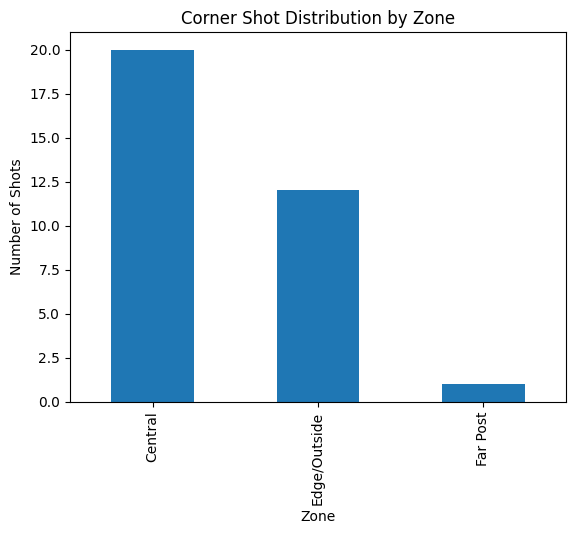

In [111]:
import matplotlib.pyplot as plt

zone_counts.plot(kind='bar')
plt.title("Corner Shot Distribution by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Shots")
plt.show()

# INSTALL & IMPORT

In [112]:
!pip install mplsoccer matplotlib --quiet

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

In [114]:
corners_df['X'] = corners_df['X'].astype(float) * 120
corners_df['Y'] = corners_df['Y'].astype(float) * 80

In [115]:
players = corners_df['player'].unique()

colors = {
    player: plt.cm.tab10(i)
    for i, player in enumerate(players)
}

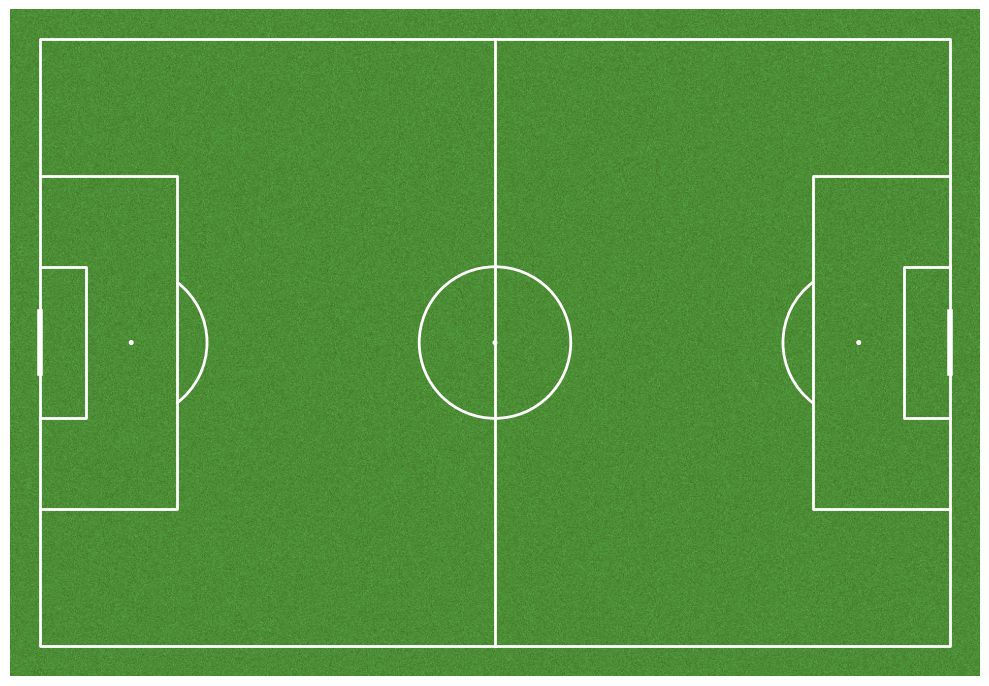

In [116]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')

fig, ax = pitch.draw(figsize=(10, 7))

In [117]:
for player in players:
    player_data = corners_df[corners_df['player'] == player]

    pitch.scatter(
        player_data['X'],
        player_data['Y'],
        s=player_data['xG'] * 800,   # size based on xG
        color=colors[player],
        edgecolors='black',
        alpha=0.8,
        label=player,
        ax=ax
    )

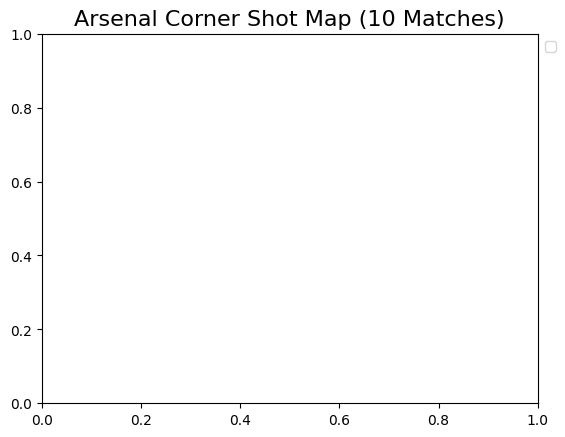

In [118]:
plt.title("Arsenal Corner Shot Map (10 Matches)", fontsize=16)

plt.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1)
)

plt.show()

Corner shots: 33

Shots by Zone:
zone
Central         21
Edge/Outside    12
Name: count, dtype: int64

xG per Zone:
zone
Central         0.220067
Edge/Outside    0.035697
Name: xG, dtype: float64

Total xG by Zone:
zone
Central         4.621410
Edge/Outside    0.428362
Name: xG, dtype: float64

Top Players:
player
Jurriën Timber        6
Gabriel               4
Leandro Trossard      4
Riccardo Calafiori    3
Noni Madueke          2
Mikel Merino          2
Ethan Nwaneri         2
Viktor Gyokeres       2
Eberechi Eze          2
Martin Odegaard       1
Ben White             1
Martín Zubimendi      1
William Saliba        1
Gabriel Martinelli    1
Bukayo Saka           1
Name: count, dtype: int64


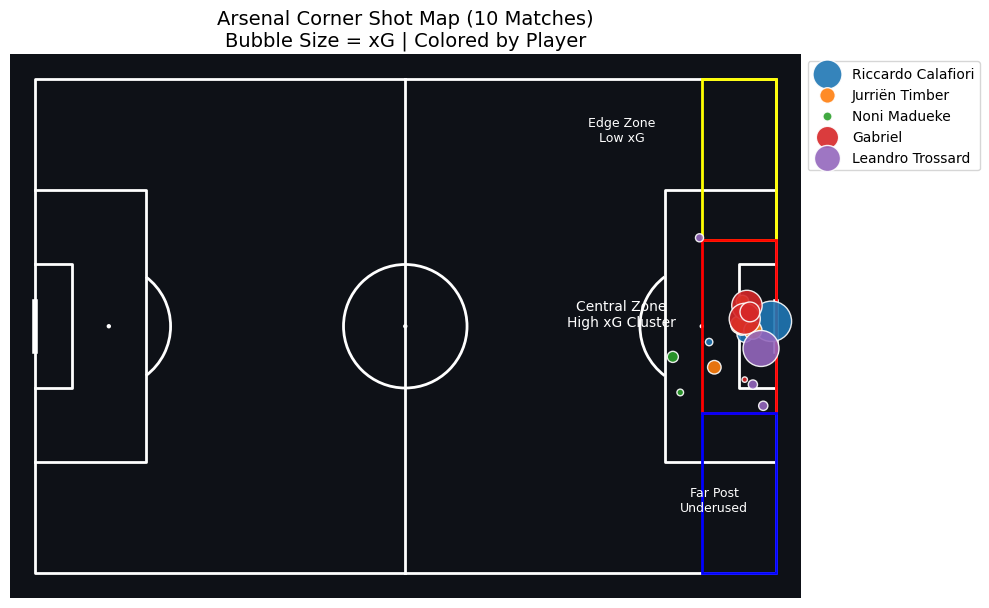

In [119]:
# ==============================
# INSTALL (run once)
# ==============================
!pip install understatapi mplsoccer matplotlib pandas --quiet

# ==============================
# IMPORTS
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import understatapi

# ==============================
# CONNECT TO UNDERSTAT
# ==============================
client = understatapi.UnderstatClient()

# ==============================
# YOUR MATCH IDS
# ==============================
match_ids = ['28786', '28793', '28806', '28808',
             '28827', '28836', '28839', '28851',
             '28859', '28869']

# ==============================
# COLLECT SHOT DATA
# ==============================
all_shots = []

for match_id in match_ids:
    try:
        shot_data = client.match(match=match_id).get_shot_data()
        shots = shot_data['h'] + shot_data['a']

        if len(shots) > 0:
            df_temp = pd.DataFrame(shots)
            df_temp['match_id'] = match_id
            all_shots.append(df_temp)

    except Exception as e:
        print(f"Error with {match_id}: {e}")

shots_df = pd.concat(all_shots, ignore_index=True)

# ==============================
# CREATE TEAM COLUMN
# ==============================
shots_df['team'] = shots_df['h_team']
shots_df.loc[shots_df['h_a'] == 'a', 'team'] = shots_df['a_team']

# ==============================
# FILTER ARSENAL CORNERS
# ==============================
corners_df = shots_df[
    (shots_df['team'] == 'Arsenal') &
    (shots_df['situation'] == 'FromCorner')
].copy()

print("Corner shots:", len(corners_df))

# ==============================
# CONVERT COORDINATES
# ==============================
corners_df['X'] = corners_df['X'].astype(float) * 120
corners_df['Y'] = corners_df['Y'].astype(float) * 80
corners_df['xG'] = corners_df['xG'].astype(float)

# ==============================
# CREATE ZONES
# ==============================
def get_zone(x, y):
    if x > 108:  # final third near goal
        if y < 26:
            return "Near Post"
        elif y > 54:
            return "Far Post"
        else:
            return "Central"
    return "Edge/Outside"

corners_df['zone'] = corners_df.apply(lambda row: get_zone(row['X'], row['Y']), axis=1)

# ==============================
# ANALYSIS
# ==============================
print("\nShots by Zone:")
print(corners_df['zone'].value_counts())

print("\nxG per Zone:")
print(corners_df.groupby('zone')['xG'].mean())

print("\nTotal xG by Zone:")
print(corners_df.groupby('zone')['xG'].sum())

print("\nTop Players:")
print(corners_df['player'].value_counts())

# ==============================
# VISUALIZATION - PITCH MAP
# ==============================

# Top 5 players only (cleaner)
top_players = corners_df['player'].value_counts().head(5).index
plot_df = corners_df[corners_df['player'].isin(top_players)]

# Assign colors
players = plot_df['player'].unique()
colors = {player: plt.cm.tab10(i) for i, player in enumerate(players)}

# Create pitch
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#0e1117',
    line_color='white'
)

fig, ax = pitch.draw(figsize=(10, 7))

# Near post zone
ax.add_patch(plt.Rectangle((108, 0), 12, 26, fill=False, edgecolor='yellow', linewidth=2))

# Central zone
ax.add_patch(plt.Rectangle((108, 26), 12, 28, fill=False, edgecolor='red', linewidth=2))

# Far post zone
ax.add_patch(plt.Rectangle((108, 54), 12, 26, fill=False, edgecolor='blue', linewidth=2))

ax.text(95, 40, "Central Zone\nHigh xG Cluster",
        color='white', fontsize=10, ha='center')

ax.text(110, 70, "Far Post\nUnderused",
        color='white', fontsize=9, ha='center')

ax.text(95, 10, "Edge Zone\nLow xG",
        color='white', fontsize=9, ha='center')

# Plot shots
for player in players:
    player_data = plot_df[plot_df['player'] == player]

    pitch.scatter(
        player_data['X'],
        player_data['Y'],
        s=player_data['xG'] * 1000,
        color=colors[player],
        edgecolors='white',
        alpha=0.9,
        label=player,
        ax=ax
    )

plt.title(
    "Arsenal Corner Shot Map (10 Matches)\nBubble Size = xG | Colored by Player",
    fontsize=14,
    color='black'
)

# Legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))


plt.show()

In [120]:
print(shots_df['situation'].unique())

['OpenPlay' 'SetPiece' 'DirectFreekick' 'FromCorner' 'Penalty']


In [121]:
corners_df = shots_df[
    (shots_df['team'] == 'Arsenal') &
    (shots_df['situation'].str.contains('FromCorner', case=False))
].copy()

In [122]:
print(corners_df[['X', 'Y']].head())

                     X                    Y
22  0.9940000152587891                 0.49
25  0.8719999694824219   0.4209999847412109
26  0.7469999694824219  0.45799999237060546
35  0.9540000152587891   0.5020000076293946
41   0.950999984741211  0.49700000762939456


In [123]:
corners_df['X'] = pd.to_numeric(corners_df['X'], errors='coerce')
corners_df['Y'] = pd.to_numeric(corners_df['Y'], errors='coerce')

corners_df = corners_df.dropna(subset=['X', 'Y'])

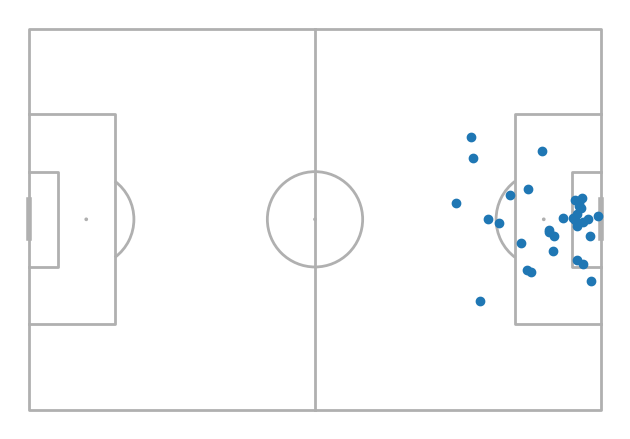

In [124]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw()

pitch.scatter(
    corners_df['X'] * 120,
    corners_df['Y'] * 80,
    ax=ax
)

plt.show()